In [10]:
import json
import os
import pandas as pd
from collections import defaultdict


In [14]:
json_file = "/user/christoph.wald/u15287/insect_pest_detection/training/predictions2/predictions_fullimage_2.json"
with open(json_file, "r") as f:
    data = json.load(f)

# Confidence ranges you want to check
conf_ranges = [(0.0, 0.1),
               (0.1, 0.2),
               (0.2, 0.3),
               (0.3, 0.4),
               (0.4, 0.5),
               (0.5, 0.6),
               (0.6, 0.7),
               (0.7, 0.8),
               (0.8, 0.9),
               (0.9, 1.0)]

# Initialize counts
counts = defaultdict(int)

# Iterate over FP predictions
for species, images in data.get("FP", {}).items():
    for img_name, entries in images.items():
        for entry in entries:
            pred = entry.get("prediction", [])
            if len(pred) < 6:
                continue  # skip malformed
            conf = pred[-1]  # last element is confidence
            for low, high in conf_ranges:
                if low <= conf < high:
                    counts[(low, high)] += 1
                    break

# Print results
print("FP counts per confidence range:")
for r in conf_ranges:
    print(f"{r}: {counts[r]}")


FP counts per confidence range:
(0.0, 0.1): 173804
(0.1, 0.2): 2493
(0.2, 0.3): 2270
(0.3, 0.4): 2045
(0.4, 0.5): 1798
(0.5, 0.6): 1411
(0.6, 0.7): 790
(0.7, 0.8): 313
(0.8, 0.9): 33
(0.9, 1.0): 0


In [12]:
json_file = "/user/christoph.wald/u15287/insect_pest_detection/training/predictions/predictions_fullimage_3.json"
with open(json_file, "r") as f:
    data = json.load(f)

# Confidence ranges you want to check
conf_ranges = [(0.0, 0.1),
               (0.1, 0.2),
               (0.2, 0.3),
               (0.3, 0.4),
               (0.4, 0.5),
               (0.5, 0.6),
               (0.6, 0.7),
               (0.7, 0.8),
               (0.8, 0.9),
               (0.9, 1.0)]

# Initialize counts
counts = defaultdict(int)

# Iterate over FP predictions
for species, images in data.get("FP", {}).items():
    for img_name, entries in images.items():
        for entry in entries:
            pred = entry.get("prediction", [])
            if len(pred) < 6:
                continue  # skip malformed
            conf = pred[-1]  # last element is confidence
            for low, high in conf_ranges:
                if low <= conf < high:
                    counts[(low, high)] += 1
                    break

# Print results
print("FP counts per confidence range:")
for r in conf_ranges:
    print(f"{r}: {counts[r]}")

FP counts per confidence range:
(0.0, 0.1): 173354
(0.1, 0.2): 2028
(0.2, 0.3): 1401
(0.3, 0.4): 1019
(0.4, 0.5): 788
(0.5, 0.6): 627
(0.6, 0.7): 438
(0.7, 0.8): 312
(0.8, 0.9): 57
(0.9, 1.0): 0


In [19]:
import json
from pathlib import Path

def check_json_structure(json_path):
    """
    Checks the structure of a YOLO prediction JSON file.
    Ensures it has 'TP', 'FP', 'FN' at top level,
    and each species maps to images -> list of predictions.
    """
    json_path = Path(json_path)
    if not json_path.exists():
        print(f"File not found: {json_path}")
        return

    with open(json_path, "r") as f:
        data = json.load(f)

    print(f"Checking JSON file: {json_path}")
    
    # Check top-level keys
    for key in ["TP", "FP", "FN"]:
        if key not in data:
            print(f"  WARNING: Missing top-level key: {key}")
        else:
            print(f"  Found key: {key}, {len(data[key])} species")

            for species, images in data[key].items():
                if not isinstance(images, dict):
                    print(f"    ERROR: species '{species}' maps to {type(images)}, expected dict")
                    continue
                print(f"    Species: {species}, {len(images)} images")
                
                for img_name, entries in images.items():
                    if not isinstance(entries, list):
                        print(f"      ERROR: image '{img_name}' maps to {type(entries)}, expected list")
                        continue
                    #print(f"      Image: {img_name}, {len(entries)} entries")
                    # Optionally, check the first entry structure
                    if entries:
                        first_entry = entries[0]
                        if "prediction" not in first_entry:
                            print(f"        WARNING: first entry missing 'prediction' key")
                        else:
                            pred_len = len(first_entry["prediction"])
                            #print(f"        First entry prediction length: {pred_len}")

# Example usage:
json_file = "/user/christoph.wald/u15287/insect_pest_detection/training/predictions2/predictions_fullimage_2.json"
check_json_structure(json_file)

Checking JSON file: /user/christoph.wald/u15287/insect_pest_detection/training/predictions2/predictions_fullimage_2.json
  Found key: TP, 3 species
    Species: BRAIIM, 119 images
    Species: LIRIBO, 386 images
    Species: TRIAVA, 113 images
  Found key: FP, 3 species
    Species: BRAIIM, 128 images
    Species: LIRIBO, 422 images
    Species: TRIAVA, 128 images
  Found key: FN, 3 species
    Species: BRAIIM, 60 images
    Species: LIRIBO, 16 images
    Species: TRIAVA, 21 images


In [2]:
import os
import shutil

def move_files_from_list(file_list_path, source_folder, destination_folder):
    """
    Moves files listed in `file_list_path` from `source_folder` to `destination_folder`.

    Args:
        file_list_path (str): Path to a text file containing one filename per line.
        source_folder (str): Folder where the files currently exist.
        destination_folder (str): Folder to move the files into.
    """
    # Check source folder
    if not os.path.isdir(source_folder):
        print(f"Error: Source folder '{source_folder}' does not exist.")
        return

    # Create destination folder if it doesn’t exist
    os.makedirs(destination_folder, exist_ok=True)

    # Read filenames
    with open(file_list_path, 'r', encoding='utf-8') as f:
        filenames = [line.strip() for line in f if line.strip()]

    # Move files
    for filename in filenames:
        src_path = os.path.join(source_folder, filename)
        dest_path = os.path.join(destination_folder, filename)

        if os.path.exists(src_path):
            try:
                shutil.move(src_path, dest_path)
                print(f"Moved: {src_path} → {dest_path}")
            except Exception as e:
                print(f"Error moving {src_path}: {e}")
        else:
            print(f"File not found: {src_path}")

move_files_from_list("/user/christoph.wald/u15287/insect_pest_detection/image_processing/logs/images_not_processed_train_labeled.txt", 
                     "/user/christoph.wald/u15287/big-scratch/04_SSL_training_data/training_data/images/train", 
                     "/user/christoph.wald/u15287/big-scratch/04_SSL_training_data/training_data/images/unprocessed")


Moved: /user/christoph.wald/u15287/big-scratch/04_SSL_training_data/training_data/images/train/LIRIBO_0552.jpg → /user/christoph.wald/u15287/big-scratch/04_SSL_training_data/training_data/images/unprocessed/LIRIBO_0552.jpg
File not found: /user/christoph.wald/u15287/big-scratch/04_SSL_training_data/training_data/images/train/BRAIIM_0778.jpg
File not found: /user/christoph.wald/u15287/big-scratch/04_SSL_training_data/training_data/images/train/LIRIBO_0563.jpg
File not found: /user/christoph.wald/u15287/big-scratch/04_SSL_training_data/training_data/images/train/LIRIBO_0554.jpg
File not found: /user/christoph.wald/u15287/big-scratch/04_SSL_training_data/training_data/images/train/TRIAVA_0430.jpg
File not found: /user/christoph.wald/u15287/big-scratch/04_SSL_training_data/training_data/images/train/TRIAVA_0434.jpg
File not found: /user/christoph.wald/u15287/big-scratch/04_SSL_training_data/training_data/images/train/LIRIBO_0527.jpg
File not found: /user/christoph.wald/u15287/big-scratch/0

In [2]:
keep = ['TRIAVA_0743.jpg',
 'BRAIIM_0112.jpg',
 'BRAIIM_1066.jpg',
 'TRIAVA_0862.jpg',
 'BRAIIM_0853.jpg',
 'BRAIIM_1024.jpg',
 'BRAIIM_1175.jpg',
 'BRAIIM_1296.jpg',
 'BRAIIM_1078.jpg',
 'TRIAVA_0811.jpg',
 'BRAIIM_1212.jpg',
 'BRAIIM_0512.jpg',
 'BRAIIM_0492.jpg',
 'TRIAVA_0738.jpg',
 'TRIAVA_1081.jpg',
 'BRAIIM_0523.jpg',
 'BRAIIM_1193.jpg',
 'TRIAVA_0770.jpg',
 'BRAIIM_0932.jpg',
 'TRIAVA_0922.jpg',
 'TRIAVA_0280.jpg',
 'TRIAVA_0728.jpg',
 'TRIAVA_0944.jpg',
 'BRAIIM_1096.jpg',
 'TRIAVA_0524.jpg',
 'TRIAVA_0523.jpg',
 'TRIAVA_0769.jpg',
 'TRIAVA_0707.jpg',
 'TRIAVA_0883.jpg',
 'TRIAVA_0968.jpg',
 'BRAIIM_1033.jpg',
 'TRIAVA_0549.jpg',
 'BRAIIM_1017.jpg',
 'TRIAVA_0885.jpg',
 'TRIAVA_0278.jpg',
 'BRAIIM_0592.jpg',
 'TRIAVA_0439.jpg',
 'BRAIIM_1214.jpg',
 'BRAIIM_0015.jpg',
 'TRIAVA_0764.jpg',
 'TRIAVA_0118.jpg',
 'BRAIIM_0580.jpg',
 'TRIAVA_0932.jpg',
 'BRAIIM_0544.jpg',
 'BRAIIM_0976.jpg',
 'TRIAVA_0662.jpg',
 'TRIAVA_0534.jpg',
 'BRAIIM_1095.jpg',
 'TRIAVA_0983.jpg',
 'TRIAVA_0891.jpg',
 'TRIAVA_0537.jpg',
 'BRAIIM_1218.jpg',
 'BRAIIM_0322.jpg',
 'TRIAVA_0688.jpg',
 'BRAIIM_0901.jpg',
 'TRIAVA_0569.jpg',
 'TRIAVA_0671.jpg',
 'TRIAVA_0563.jpg',
 'TRIAVA_0685.jpg',
 'BRAIIM_1048.jpg',
 'TRIAVA_0817.jpg',
 'TRIAVA_0735.jpg',
 'BRAIIM_0127.jpg',
 'BRAIIM_0511.jpg',
 'TRIAVA_1005.jpg',
 'BRAIIM_0503.jpg',
 'TRIAVA_0228.jpg',
 'TRIAVA_0385.jpg',
 'TRIAVA_0057.jpg',
 'TRIAVA_0889.jpg',
 'BRAIIM_0854.jpg',
 'TRIAVA_0786.jpg',
 'TRIAVA_0134.jpg',
 'BRAIIM_0970.jpg',
 'BRAIIM_0996.jpg',
 'BRAIIM_0318.jpg',
 'TRIAVA_1100.jpg',
 'TRIAVA_0936.jpg',
 'BRAIIM_1162.jpg',
 'TRIAVA_1076.jpg',
 'TRIAVA_0821.jpg',
 'TRIAVA_0107.jpg',
 'TRIAVA_0556.jpg',
 'TRIAVA_0314.jpg',
 'TRIAVA_0174.jpg',
 'BRAIIM_1178.jpg',
 'TRIAVA_0833.jpg',
 'TRIAVA_0401.jpg',
 'TRIAVA_0462.jpg',
 'TRIAVA_0499.jpg',
 'TRIAVA_0840.jpg',
 'BRAIIM_0528.jpg',
 'BRAIIM_0142.jpg',
 'TRIAVA_0762.jpg',
 'BRAIIM_0575.jpg',
 'BRAIIM_0482.jpg',
 'BRAIIM_0346.jpg',
 'TRIAVA_0173.jpg',
 'BRAIIM_1084.jpg',
 'TRIAVA_0479.jpg',
 'TRIAVA_0887.jpg',
 'TRIAVA_0604.jpg',
 'TRIAVA_0713.jpg',
 'TRIAVA_0875.jpg',
 'TRIAVA_0963.jpg',
 'BRAIIM_0568.jpg',
 'TRIAVA_0679.jpg',
 'TRIAVA_1082.jpg',
 'BRAIIM_1203.jpg',
 'BRAIIM_0850.jpg',
 'TRIAVA_0558.jpg',
 'TRIAVA_0367.jpg',
 'TRIAVA_0404.jpg',
 'TRIAVA_0279.jpg',
 'TRIAVA_0054.jpg',
 'TRIAVA_0798.jpg',
 'BRAIIM_0172.jpg',
 'BRAIIM_1110.jpg',
 'TRIAVA_0974.jpg',
 'BRAIIM_0327.jpg',
 'BRAIIM_1179.jpg',
 'TRIAVA_0396.jpg',
 'BRAIIM_0578.jpg',
 'TRIAVA_0411.jpg',
 'TRIAVA_0163.jpg',
 'BRAIIM_0540.jpg',
 'BRAIIM_0986.jpg',
 'TRIAVA_0999.jpg',
 'TRIAVA_0621.jpg',
 'TRIAVA_0844.jpg',
 'TRIAVA_0710.jpg',
 'BRAIIM_1253.jpg',
 'TRIAVA_1007.jpg',
 'TRIAVA_0641.jpg',
 'BRAIIM_0805.jpg',
 'TRIAVA_0702.jpg',
 'BRAIIM_0131.jpg',
 'TRIAVA_0426.jpg',
 'TRIAVA_0557.jpg',
 'BRAIIM_0281.jpg',
 'TRIAVA_1094.jpg',
 'BRAIIM_1209.jpg',
 'TRIAVA_0383.jpg',
 'BRAIIM_1302.jpg',
 'TRIAVA_0442.jpg',
 'BRAIIM_0678.jpg',
 'BRAIIM_1006.jpg',
 'BRAIIM_0216.jpg',
 'TRIAVA_0513.jpg',
 'TRIAVA_0979.jpg',
 'TRIAVA_0355.jpg',
 'TRIAVA_0519.jpg',
 'TRIAVA_0192.jpg',
 'BRAIIM_1142.jpg',
 'TRIAVA_0640.jpg',
 'BRAIIM_0785.jpg',
 'TRIAVA_0102.jpg']

In [7]:
import os
import shutil


# Source and destination folders
folder_a = r"/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_unlabeled/05_created_labels"
folder_b = r"/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_unlabeled/05_created_labels_reduced"

# Make sure destination folder exists
os.makedirs(folder_b, exist_ok=True)

# Copy each file
for filename in keep:
    filename = os.path.splitext(filename)[0] + ".txt"
    src_path = os.path.join(folder_a, filename)
    dst_path = os.path.join(folder_b, filename)
    
    if os.path.exists(src_path):
        shutil.copy2(src_path, dst_path)
        print(f"Copied: {filename}")
    else:
        print(f"File not found: {filename}")

print("Done!")


Copied: TRIAVA_0743.txt
Copied: BRAIIM_0112.txt
Copied: BRAIIM_1066.txt
Copied: TRIAVA_0862.txt
Copied: BRAIIM_0853.txt
Copied: BRAIIM_1024.txt
Copied: BRAIIM_1175.txt
Copied: BRAIIM_1296.txt
Copied: BRAIIM_1078.txt
Copied: TRIAVA_0811.txt
Copied: BRAIIM_1212.txt
Copied: BRAIIM_0512.txt
Copied: BRAIIM_0492.txt
Copied: TRIAVA_0738.txt
Copied: TRIAVA_1081.txt
Copied: BRAIIM_0523.txt
Copied: BRAIIM_1193.txt
Copied: TRIAVA_0770.txt
Copied: BRAIIM_0932.txt
Copied: TRIAVA_0922.txt
Copied: TRIAVA_0280.txt
Copied: TRIAVA_0728.txt
Copied: TRIAVA_0944.txt
Copied: BRAIIM_1096.txt
Copied: TRIAVA_0524.txt
Copied: TRIAVA_0523.txt
Copied: TRIAVA_0769.txt
Copied: TRIAVA_0707.txt
Copied: TRIAVA_0883.txt
Copied: TRIAVA_0968.txt
Copied: BRAIIM_1033.txt
Copied: TRIAVA_0549.txt
Copied: BRAIIM_1017.txt
Copied: TRIAVA_0885.txt
Copied: TRIAVA_0278.txt
Copied: BRAIIM_0592.txt
Copied: TRIAVA_0439.txt
Copied: BRAIIM_1214.txt
Copied: BRAIIM_0015.txt
Copied: TRIAVA_0764.txt
Copied: TRIAVA_0118.txt
Copied: BRAIIM_0

In [8]:
import os

In [26]:
label_path =  "/user/christoph.wald/u15287/big-scratch/04_SSL_training_data/training_data_reduced/labels/train"
image_path = "/user/christoph.wald/u15287/big-scratch/04_SSL_training_data/training_data_reduced/images/train"
print(len(os.listdir(label_path)))
print(len(os.listdir(image_path)))

680
680


In [25]:
label_path =  "/user/christoph.wald/u15287/big-scratch/04_SSL_training_data/training_data_reduced/labels/train"
image_path = "/user/christoph.wald/u15287/big-scratch/04_SSL_training_data/training_data_reduced/images/train"
rm = []
for file in os.listdir(image_path):
    txt_file = os.path.splitext(file)[0] + ".txt"
    if txt_file not in os.listdir(label_path):
        remove = os.path.join(image_path, file)
        os.remove(remove)
        rm.append(remove)
print(len(rm))

27


In [1]:
def plot_split(df, output_dir = "split_plots", filename = "splitting"):
    """
    Plots a horizontal stacked bar plot for each row of a transposed DataFrame.
    Each column (original data row) contributes a segment starting at multiples of 200.
    Includes dotted vertical lines every 200 units and a legend based on column names.
    """

    rows = df.index  # Now rows are the metrics (e.g. dataset1_count, etc.)
    col_labels = df.columns  # These represent your data keys (e.g., folder1, folder2)
    num_cols = len(col_labels)

    fig, ax = plt.subplots(figsize=(12, 6))

    left_offsets = np.arange(num_cols) * 600

    # Draw bars
    for i, row in enumerate(rows):
        values = df.loc[row].values
        for j, value in enumerate(values):
            start = left_offsets[j]
            color = f"C{j}"
            ax.barh(y=i, width=value, left=start, height=0.8, color=color, edgecolor="black")

            # Add value label
            if value > 10:
                ax.text(start + value / 2, i, str(value), va='center', ha='center', color='white', fontsize=9)
            else:
                ax.text(start + value + 3, i, str(value), va='center', ha='left', color='black', fontsize=9)

    # Set y-axis
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels(rows)
    ax.set_xlabel('Value')
    ax.set_title('Dataset splitting')

    # Dotted vertical lines every 200 units
    max_x = left_offsets[-1] + 600
    for x in range(0, int(max_x + 200), 200):
        ax.axvline(x=x, color='gray', linestyle='dotted', linewidth=1)

    # Create custom legend for columns
    legend_patches = [
        mpatches.Patch(color=f"C{i}", label=str(col_labels[i]))
        for i in range(num_cols)
    ]
    ax.legend(handles=legend_patches, title="Data Columns", bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.tight_layout()
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, filename)
    plt.savefig(output_path)
    plt.close()

In [3]:
import matplotlib.pyplot as plt

In [11]:
import cv2
import numpy as np
import os

def read_yolo_labels(label_path, img_width, img_height):
    boxes = []
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            _, x, y, w, h = map(float, parts)
            x1 = int((x - w / 2) * img_width)
            y1 = int((y - h / 2) * img_height)
            x2 = int((x + w / 2) * img_width)
            y2 = int((y + h / 2) * img_height)
            boxes.append((x1, y1, x2, y2))
    return boxes

def crop_boxes(image, boxes, max_boxes=10):
    crops = []
    for box in boxes[:max_boxes]:
        x1, y1, x2, y2 = box
        crop = image[max(y1, 0):y2, max(x1, 0):x2]
        if crop.size > 0:
            crops.append(crop)
    return crops

def pad_to_cell(img, cell_size):
    """Pad (not resize) image to center it inside a fixed cell size."""
    cell_h, cell_w = cell_size
    h, w = img.shape[:2]
    canvas = np.ones((cell_h, cell_w, 3), dtype=np.uint8) * 255  # white background
    y_off = max((cell_h - h) // 2, 0)
    x_off = max((cell_w - w) // 2, 0)
    # clip if the crop is larger than the cell (shouldn’t happen, but just in case)
    y_end = min(y_off + h, cell_h)
    x_end = min(x_off + w, cell_w)
    canvas[y_off:y_end, x_off:x_end] = img[:y_end - y_off, :x_end - x_off]
    return canvas

def create_grid(images_crops, line_thickness=3):
    """
    Create a 4x10 grid with equal cell size, 
    boxes centered (original size, not resized), 
    and black lines separating cells and rows.
    """
    # Flatten all crops to compute the maximum required cell size
    all_crops = [c for row in images_crops for c in row]
    if not all_crops:
        raise ValueError("No crops found to create grid.")
    
    max_h = max(c.shape[0] for c in all_crops)
    max_w = max(c.shape[1] for c in all_crops)
    cell_size = (max_h, max_w)

    grid_rows = []
    for i, row_crops in enumerate(images_crops):
        row_cells = []
        for j in range(10):
            if j < len(row_crops):
                cell = pad_to_cell(row_crops[j], cell_size)
            else:
                cell = np.ones((max_h, max_w, 3), dtype=np.uint8) * 255  # empty white cell
            row_cells.append(cell)
            if j < 9:
                row_cells.append(np.zeros((max_h, line_thickness, 3), dtype=np.uint8))  # vertical line

        row_img = np.concatenate(row_cells, axis=1)
        grid_rows.append(row_img)

        if i < len(images_crops) - 1:
            grid_rows.append(np.zeros((line_thickness, row_img.shape[1], 3), dtype=np.uint8))  # horizontal line

    grid = np.concatenate(grid_rows, axis=0)
    return grid

def main(base_filenames):
    all_crops = []
    for base in base_filenames:
        img_path = os.path.join("/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/test_set_w_new_labels/images", base + '.jpg')
        label_path = os.path.join("/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/test_set_w_new_labels/labels", base + '.txt')

        if not os.path.exists(img_path) or not os.path.exists(label_path):
            print(f"Skipping {base}: missing image or label file")
            all_crops.append([])
            continue

        img = cv2.imread(img_path)
        h, w = img.shape[:2]
        boxes = read_yolo_labels(label_path, w, h)
        crops = crop_boxes(img, boxes, max_boxes=10)
        all_crops.append(crops)
    
    grid = create_grid(all_crops)
    cv2.imwrite("/user/christoph.wald/u15287/insect_pest_detection/BA/grid_output.jpg", grid)
    print("✅ Saved grid as grid_output.jpg")




In [12]:
main(["BRAIIM_0170", "LIRIBO_0181","FRANOC_0042", "TRIAVA_0465"])

✅ Saved grid as grid_output.jpg


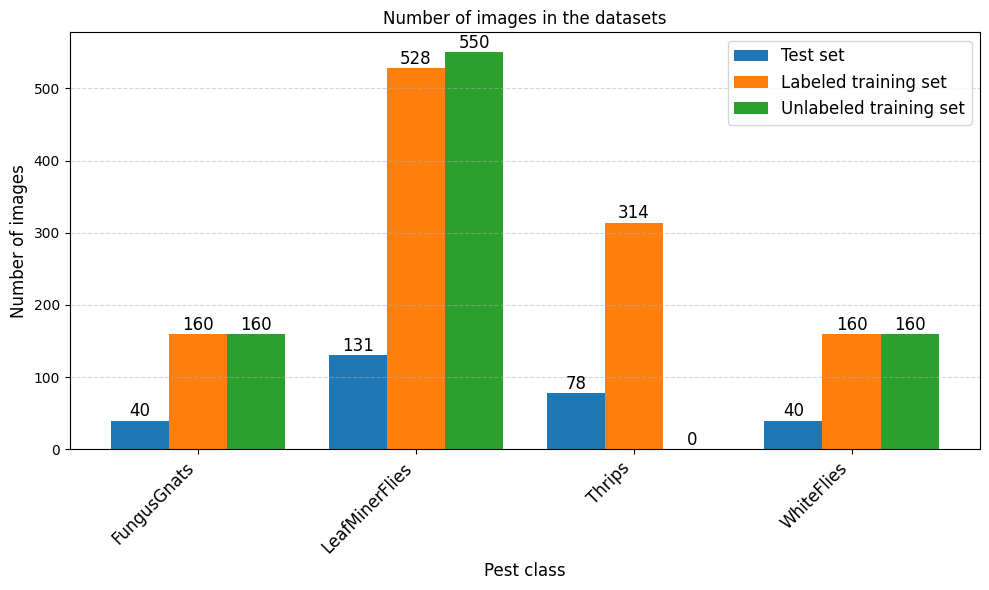

In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np

def count_species_entries(json_paths):
    """Number of Images in datasets."""
    all_counts = []

    for path in json_paths:
        with open(path, 'r') as f:
            data = json.load(f)
        counts = {species: len(entries) for species, entries in data.items()}
        all_counts.append(counts)

    # Collect all unique species names
    all_species = sorted(set().union(*[d.keys() for d in all_counts]))

    # Build a matrix of counts
    matrix = []
    for d in all_counts:
        matrix.append([d.get(species, 0) for species in all_species])
    
    return all_species, np.array(matrix)

def plot_species_counts(json_paths, labels):
    all_species, counts = count_species_entries(json_paths)

    n_files = len(json_paths)
    x = np.arange(len(all_species))
    bar_width = 0.8 / n_files  # adjust spacing

    plt.figure(figsize=(10, 6))
    bars = []
    for i in range(n_files):
        bars_i = plt.bar(x + i * bar_width, counts[i], width=bar_width, label=labels[i])
        bars.append(bars_i)
        # Add text labels
        for bar in bars_i:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,  # x position (center)
                height + 0.3,                       # y position (slightly above bar)
                f"{int(height)}",                   # label text
                ha='center', va='bottom', fontsize=12
            )

    plt.xticks(x + bar_width * (n_files - 1) / 2, all_species, rotation=45, ha='right', fontsize = 12)
    plt.ylabel("Number of images", fontsize = 12)
    plt.xlabel("Pest class", fontsize =12)
    plt.title("Number of images in the datasets", fontsize = 12)
    plt.legend(fontsize = 12)
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.savefig("/user/christoph.wald/u15287/insect_pest_detection/BA/split.png")
    plt.show()



# Replace with your actual file paths
json_files = ["/user/christoph.wald/u15287/big-scratch/02_splitted_data/split_info/test_set.json", 
              "/user/christoph.wald/u15287/big-scratch/02_splitted_data/split_info/train_labeled.json",
                "/user/christoph.wald/u15287/big-scratch/02_splitted_data/split_info/train_unlabeled.json"]
labels = ["Test set", "Labeled training set", "Unlabeled training set"]

plot_species_counts(json_files, labels)


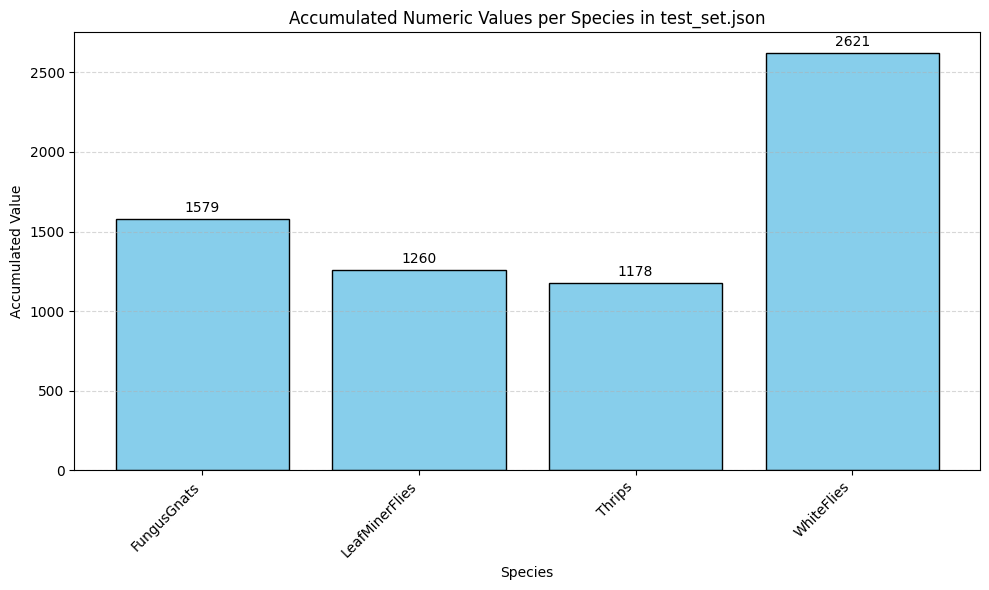

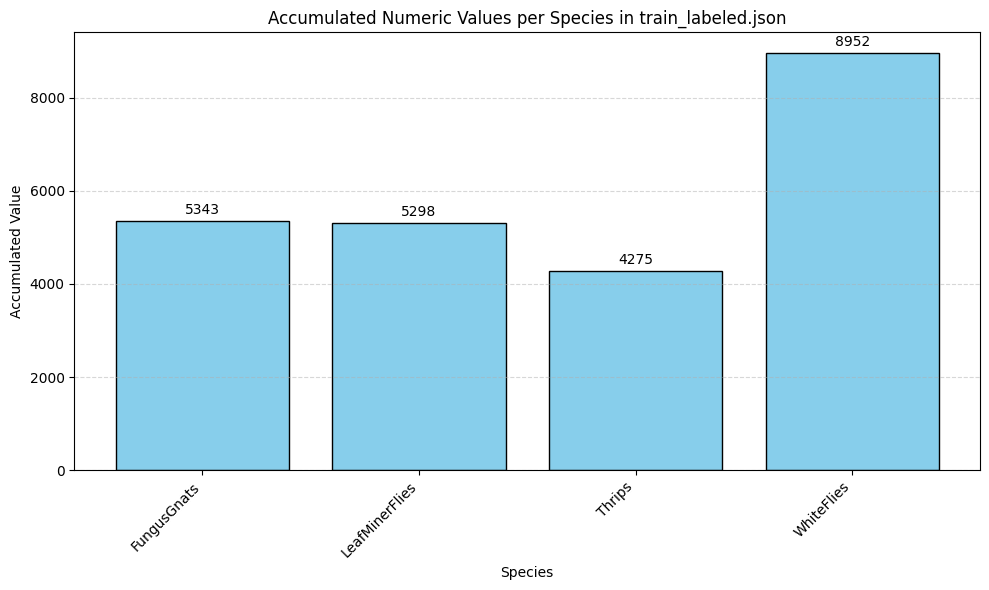

In [21]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_accumulated_per_json(json_paths):
    """For each JSON file, plot accumulated numeric values per species."""
    for path in json_paths:
        if not os.path.exists(path):
            print(f"⚠️ File not found: {path}")
            continue

        with open(path, 'r') as f:
            data = json.load(f)

        species = sorted(data.keys())
        sums = [sum(data[sp].values()) for sp in species]

        x = np.arange(len(species))

        plt.figure(figsize=(10, 6))
        bars = plt.bar(x, sums, color='skyblue', edgecolor='black')
        for bar, value in zip(bars, sums):
            plt.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height() + max(sums) * 0.01,
                str(value), ha='center', va='bottom', fontsize=10
            )

        plt.xticks(x, species, rotation=45, ha='right')
        plt.ylabel("Accumulated Value")
        plt.xlabel("Species")
        plt.title(f"Accumulated Numeric Values per Species in {os.path.basename(path)}")
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

json_files = ["/user/christoph.wald/u15287/big-scratch/02_splitted_data/split_info/test_set.json", 
              "/user/christoph.wald/u15287/big-scratch/02_splitted_data/split_info/train_labeled.json"]
labels = ["Test set", "Labeled training set", "Unlabeled training set"]
plot_accumulated_per_json(json_files)


In [8]:
import json
import os
import cv2

# ---------------------------------------------------------
# COLORS (OpenCV uses BGR)
# ---------------------------------------------------------
COLOR_FN = (0, 0, 255)    # red
COLOR_TP = (0, 255, 0)    # green
COLOR_FP = (255, 0, 0)    # blue

# ---------------------------------------------------------
# Load JSON
# ---------------------------------------------------------
def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

# ---------------------------------------------------------
# Draw boxes helper WITH CONF THRESHOLD
# ---------------------------------------------------------
def draw_boxes(image, boxes, color, label, conf_threshold):
    for box in boxes:
        pred = box["prediction"]

        # FN: [cls, x1, y1, x2, y2]
        # TP/FP: [cls, x1, y1, x2, y2, conf]
        if len(pred) == 5:
            cls, x1, y1, x2, y2 = pred
            conf = None
        else:
            cls, x1, y1, x2, y2, conf = pred
            # Skip if confidence below threshold
            if conf < conf_threshold:
                continue

        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

        if conf is None:
            txt = label
        else:
            txt = f"{label} {conf:.2f}"

        cv2.putText(image, txt, (x1, max(0, y1 - 4)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

# ---------------------------------------------------------
# Combine FN/TP/FP and SAVE annotated images
# ---------------------------------------------------------
def save_all_per_image(json_data, image_folder, output_folder, conf_threshold=0.0):

    os.makedirs(output_folder, exist_ok=True)

    # image_name -> { "FN": [...], "TP": [...], "FP": [...] }
    collected = {}

    # Collect all boxes
    for category in ["FN", "FP", "TP"]:
        if category not in json_data:
            continue

        species_dict = json_data[category]

        for species, images_dict in species_dict.items():
            for img_name, boxes in images_dict.items():

                if img_name not in collected:
                    collected[img_name] = {"FN": [], "FP": [], "TP": []}

                collected[img_name][category].extend(boxes)

    # Process each image
    for img_name, groups in collected.items():

        img_path = os.path.join(image_folder, img_name)
        img = cv2.imread(img_path)

        if img is None:
            print(f"[WARNING] Cannot load: {img_path}")
            continue

        # Draw all categories with confidence threshold
        draw_boxes(img, groups["FN"], COLOR_FN, "FN", conf_threshold)
        draw_boxes(img, groups["TP"], COLOR_TP, "TP", conf_threshold)
        draw_boxes(img, groups["FP"], COLOR_FP, "FP", conf_threshold)

        # Save output
        save_path = os.path.join(output_folder, img_name)
        cv2.imwrite(save_path, img)

        print(f"[SAVED] {save_path}")

# ---------------------------------------------------------
# Example usage:
# ---------------------------------------------------------
# json_data = load_json("predictions.json")
# save_all_per_image(json_data,
#                    image_folder="/path/to/images/",
#                    output_folder="annotated_output",
#                    conf_threshold=0.5)   # <- set threshold here


In [10]:

json_data = load_json("/user/christoph.wald/u15287/insect_pest_detection/training/predictions/predictions_fullimage_16.json")
save_all_per_image(json_data, 
                   "/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/test_set_w_new_labels/images", 
                   "/user/christoph.wald/u15287/big-scratch/testcheck",
                   conf_threshold= 0.25)


[SAVED] /user/christoph.wald/u15287/big-scratch/testcheck/BRAIIM_0157.jpg
[SAVED] /user/christoph.wald/u15287/big-scratch/testcheck/BRAIIM_0170.jpg
[SAVED] /user/christoph.wald/u15287/big-scratch/testcheck/BRAIIM_0184.jpg
[SAVED] /user/christoph.wald/u15287/big-scratch/testcheck/BRAIIM_0195.jpg
[SAVED] /user/christoph.wald/u15287/big-scratch/testcheck/BRAIIM_0204.jpg
[SAVED] /user/christoph.wald/u15287/big-scratch/testcheck/BRAIIM_0207.jpg
[SAVED] /user/christoph.wald/u15287/big-scratch/testcheck/BRAIIM_0223.jpg
[SAVED] /user/christoph.wald/u15287/big-scratch/testcheck/BRAIIM_0286.jpg
[SAVED] /user/christoph.wald/u15287/big-scratch/testcheck/BRAIIM_0288.jpg
[SAVED] /user/christoph.wald/u15287/big-scratch/testcheck/BRAIIM_0302.jpg
[SAVED] /user/christoph.wald/u15287/big-scratch/testcheck/BRAIIM_0319.jpg
[SAVED] /user/christoph.wald/u15287/big-scratch/testcheck/BRAIIM_0384.jpg
[SAVED] /user/christoph.wald/u15287/big-scratch/testcheck/BRAIIM_0403.jpg
[SAVED] /user/christoph.wald/u15287/bi